# TI3145TU Final Assignment 
## Health Insurance 

We hope you enjoy this assignment, good luck!

Student names: XXX

Student numbers: XXX

### Imports

In [37]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

### Load data

In [38]:
# These are your training samples along with their labels
data = pd.read_csv('health_insurance_train.csv')
data.head()

# You need to extract the features and the regression target. The regression target is 'whrswk'. 

,whrswk,hhi,whi,hhi2,education,race,hispanic,experience,kidslt6,kids618,husby,region
0,40.0,no,yes,yes,13-15years,white,no,17.0,0.0,1.0,22.000,south
1,40.0,no,yes,yes,13-15years,white,no,4.0,1.0,0.0,15.000,south
2,0.0,yes,no,yes,16years,white,no,21.0,0.0,1.0,99.999,other
3,40.0,no,no,yes,13-15years,white,no,22.0,NaN,NaN,60.000,northcentral
4,35.0,no,yes,no,12years,white,no,15.0,0.0,2.0,0.000,south


### Pipeline 1

In [39]:
import numpy as np
import pandas as pd
import sklearn

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# These are your training samples along with their labels
data = pd.read_csv('health_insurance_train.csv')
# Here we separate target (y) and features (X)
X = data.drop('whrswk', axis=1)
y = data['whrswk']
# divide columns into numerical and non-numerical features
#numerical_feats = ['experience', 'kidslt6', 'kids618', 'husby']
#categorical_feats = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']
# transformer for numbers
#numerical_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy="median")), ('scaler', StandardScaler())])
# transformer for non-numbers
#categorical_transf = Pipeline(steps=[('imputer', SimpleImputer(strategy="most_frequent")), ('encoder', OneHotEncoder())])
#
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', numerical_transf, numerical_feats),
#        ('cat', categorical_transf, categorical_feats)
#    ]
#)

#preprocessor.fit(X)

#X_transformed = preprocessor.transform(X)

#print(X_transformed[0])
# You need to extract the features and the regression target. The regression target is 'whrswk'.


# ---------------------
# Pipeline 1: Simple baseline pipeline
# ---------------------
numerical_feats_1 = ['experience', 'kidslt6', 'kids618', 'husby']
categorical_feats_1 = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']

numerical_transf_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transf_1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor1 = ColumnTransformer([
    ('num', numerical_transf_1, numerical_feats_1),
    ('cat', categorical_transf_1, categorical_feats_1)
])

# ---------------------
# Pipeline 2: Engineered + scaled pipeline
# ---------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Separate numerical features — we'll split them into two groups
poly_feat = ['experience']
other_num_feats = ['kidslt6', 'kids618', 'husby']
cat_feats = ['hhi', 'whi', 'hhi2', 'education', 'race', 'hispanic', 'region']

# Transformer for the polynomial 'experience' feature
poly_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Transformer for other numeric features (no polynomial)
other_num_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer for categorical features
cat_transf = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine all transformations
preprocessor2 = ColumnTransformer([
    ('poly', poly_transf, poly_feat),
    ('num', other_num_transf, other_num_feats),
    ('cat', cat_transf, cat_feats)
])



### Dummy regressor

In [40]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error

dummy = DummyRegressor(strategy="mean")
dummy.fit(X, y)
y_pred = dummy.predict(X)
mae_baseline = mean_absolute_error(y, y_pred)
print("Baseline MAE (DummyRegressor, mean strategy):", mae_baseline)

Baseline MAE (DummyRegressor, mean strategy): 16.97666512


### Model training

In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error


models = {
    "KNN": KNeighborsRegressor(),
    "SGD": SGDRegressor(random_state=42),  # add random_state for reproducibility
    "RandomForest": RandomForestRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42)
}
results = {}

# Loop over models
for name, model in models.items():
    # Create full pipeline: preprocessing + model
    full_pipeline = Pipeline([('preprocessor', preprocessor2),  ('regressor', model)])
    #full_pipeline = make_pipeline2_simple(model)
    # Cross-validated MAE (5-fold CV)
    cv_scores = cross_val_score(full_pipeline, X, y, cv=5, scoring='neg_mean_absolute_error')
    
    # Convert negative MAE to positive
    mae = -cv_scores.mean()
    
    results[name] = mae
    print(name, results[name])

    


KNN 12.256519999999998
SGD 11.980481541984751
RandomForest 11.8080129018426
DecisionTree 14.157187619047619


### Tuning


🔍 Grid Search for KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=3, regressor__min_samples_leaf=2, regressor__min_samples_split=10; total time=   0.0s
[CV] END regre

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stocha

[CV] END regressor__alpha=0.001, regressor__eta0=0.1, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=elasticnet; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.1, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=elasticnet; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.1, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=elasticnet; total time=   0.1s
[CV] END regressor__alpha=0.01, regressor__eta0=0.001, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.001, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.001, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stocha

[CV] END regressor__alpha=0.001, regressor__eta0=0.01, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.01, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.01, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.01, regressor__learning_rate=optimal, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.1s
[CV] END regressor__alpha=0.001, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=elasticnet; total time=   0.0s
[CV] END regressor__alpha=0.001, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=10000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.001, regresso

...

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stocha

[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l1; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l1; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l1; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__learning_rate=constant, regressor__max_iter=5000, regressor__penalty=l1; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.1, regressor__

/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1616: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_stocha

✅ Best MAE for SGD: 11.9781
   Best params: {'regressor__alpha': 0.0001, 'regressor__eta0': 0.001, 'regressor__learning_rate': 'constant', 'regressor__max_iter': 5000, 'regressor__penalty': 'l1'}

🔍 Grid Search for RandomForest
Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END regressor__alpha=0.01, regressor__eta0=0.01, regressor__learning_rate=constant, regressor__max_iter=10000, regressor__penalty=elasticnet; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.01, regressor__learning_rate=constant, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.01, regressor__learning_rate=constant, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.01, regressor__learning_rate=constant, regressor__max_iter=100000, regressor__penalty=l2; total time=   0.0s
[CV] END regressor__alpha=0.01, regressor__eta0=0.01, regressor__le

,MAE,regressor__n_neighbors,regressor__p,regressor__weights,regressor__alpha,regressor__eta0,regressor__learning_rate,regressor__max_iter,regressor__penalty,regressor__max_depth,regressor__min_samples_leaf,regressor__min_samples_split,regressor__n_estimators,regressor__criterion
KNN,11.886236,11,1,uniform,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SGD,11.978088,NaN,NaN,NaN,0.0001,0.001,constant,5000,l1,NaN,NaN,NaN,NaN,NaN
RandomForest,11.364441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,4.0,10.0,200.0,NaN
DecisionTree,11.673618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,5,NaN,squared_error


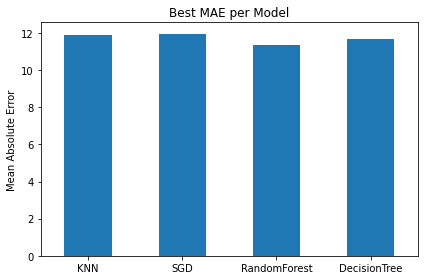

[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=5; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_leaf=4, regressor__min_samples_split=2; total time=   0.0s
[CV] END regressor__criterion=friedman_mse, regressor__max_depth=10, regressor__min_samples_le

In [46]:
# =======================================================
# 3.2 Hyperparameter Tuning with GridSearchCV
# =======================================================
from sklearn.model_selection import GridSearchCV, KFold
import pandas as pd
#from pyplot import matplotlib### Tuningplot as plt

# Cross-validation scheme: reproducible and stratified
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the parameter grids
param_grids = {
    'KNN': {
        'regressor__n_neighbors': [3, 5, 7, 9, 11],
        'regressor__weights': ['uniform', 'distance'],
        'regressor__p': [1, 2]  # L1 (Manhattan) vs L2 (Euclidean)
    },
    'SGD': {
        'regressor__alpha': [1e-4, 1e-3, 1e-2],
        'regressor__penalty': ['l2', 'l1', 'elasticnet'],
        'regressor__learning_rate': ['constant', 'optimal'],
        'regressor__eta0': [0.001, 0.01, 0.1],
        'regressor__max_iter': [5000, 10000, 100000]
    },
    'DecisionTree': {
        'regressor__max_depth': [3, 5, 10, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4],
        'regressor__criterion': ['squared_error', 'friedman_mse']
    },
    'RandomForest': {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [5, 10, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4]
    }
}

grid_results = {}

# Perform exhaustive grid search for each model
for name, model in models.items():
    print(f"\n🔍 Grid Search for {name}")
    
    # Build the pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor2),
        ('regressor', model)
    ])
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1,
        verbose=2
    )
    
    # Fit search
    grid_search.fit(X, y)
    
    # Save results
    grid_results[name] = {
        'best_MAE': -grid_search.best_score_,
        'best_params': grid_search.best_params_
    }
    
    print(f"✅ Best MAE for {name}: {-grid_search.best_score_:.4f}")
    print(f"   Best params: {grid_search.best_params_}")

# Summarize in a DataFrame
summary = pd.DataFrame({
    k: {'MAE': v['best_MAE'], **v['best_params']} for k, v in grid_results.items()
}).T

print("\n=== Grid Search Summary ===")
display(summary)

# Optional: visualize performance
summary['MAE'].plot(kind='bar', title='Best MAE per Model', ylabel='Mean Absolute Error', rot=0)
plt.tight_layout()
plt.show()


### Autograder 

In the autograder you will need to provide two things: 1) estimate of the MAE of your model on unseen data, 2) the predictions on the autograder data. For the autograder data we only provide the features and not the regression targets. Thus, you cannot compute the MAE on this data yourself - you need to estimate that with the data provided above. 

In [5]:
data_autograder = pd.read_csv('health_insurance_autograde.csv')
data_autograder.head()


,hhi,whi,hhi2,education,race,hispanic,experience,kidslt6,kids618,husby,region
0,no,yes,no,16years,white,no,25.0,0.0,0.0,0.0,west
1,no,no,no,12years,white,no,41.0,0.0,0.0,0.0,south
2,yes,yes,yes,>16years,white,no,21.0,0.0,2.0,34.3,other
3,no,yes,yes,9-11years,NaN,no,46.5,0.0,0.0,0.0,other
4,no,no,no,13-15years,white,no,9.0,0.0,0.0,25.0,northcentral


In [13]:
# TODO Replace this with your own estimate of the MAE of your best model
estimate_MAE_on_new_data = 11.816

# TODO Replace this with the predictions of your best model
# via e.g. prediction = model.predict(data_autograder)
predictions_autograder_data = np.array([-1] * 17272)

# Upload this file to the Vocareum autograder:
result = np.append(estimate_MAE_on_new_data, predictions_autograder_data)
pd.DataFrame(result).to_csv("autograder_submission.txt", index=False, header=False)